# KI/NUM — zápočtová úloha č. 1

**Jiří Škvor**

---

## Zadání

Mějte soustavu lineárních rovnic $A\vec{x} = \vec{b}$, kde prvky matice $A$ jsou určeny vztahem

$$A_{ij} = \int_0^1 t^{i+j-2} \, dt \quad \text{pro } i, j = 1, \dots, N$$

a prvky vektoru pravých stran $\vec{b}$ jsou určeny vztahem

$$b_i = \sum_{j=1}^{N} A_{ij} \quad \text{pro } i = 1, \dots, N$$

Potřebné hodnoty určitého integrálu vypočítejte libovolnou **numerickou metodou** (vlastní implementace — ne analyticky, ne `scipy.integrate`).

Úlohu řešte pro počet neznámých $N = 2, \dots, 20$.

---

## Požadavky

1. **Sestavení matice $A$** — každý prvek $A_{ij}$ vypočítejte numerickou integrací vlastní implementací (Simpson, lichoběžník, Gauss — cokoliv z repozitáře).

2. **Řešení soustavy** — použijte vlastní solver ze svého repozitáře (Gaussova eliminace, LU rozklad nebo varianta s pivotací). Knihovní `numpy.linalg.solve` není povoleno jako primární solver.

3. **Ověření analytického řešení** — ukažte (matematicky nebo kódem), proč je $\vec{x} = \vec{1}$ analytickým řešením této soustavy pro libovolné $N$.

4. **Chyba řešení** — pro každé $N$ spočítejte

$$\varepsilon(N) = \|\vec{x} - \vec{1}\|_\infty = \max_{i} |x_i - 1|$$

5. **Graf** — vykreslete $\varepsilon(N)$ jako funkci $N$ (osa $x$: hodnoty $N = 2, \dots, 20$, osa $y$: chyba v logaritmickém měřítku).

6. **Komentář** — okomentujte slovně, co se děje s chybou jak roste $N$ a proč. Nápověda: zamyslete se nad podmíněností matice $A$.

---

## Nápověda

- Analytická hodnota integrálu je $A_{ij} = \frac{1}{i+j-1}$ — tuto hodnotu **nepoužívejte** při výpočtu, ale můžete ji použít k ověření, že vaše numerická integrace funguje správně.
- Matice $A$ je tzv. **Hilbertova matice** — jedna z nejznámějších špatně podmíněných matic. Číslo podmíněnosti $\kappa(A)$ roste velmi rychle s $N$.
- Pro výpočet integrálu stačí $n = 1000$ podintervalů.

---

## Odevzdání

- Jeden `.py` soubor (nebo `.ipynb`) s komentáři
- Graf chyby jako součást výstupu skriptu
- Slovní komentář ke kondici matice (stačí pár vět v kódu jako `# komentář`)

[[1.0000000000000002, 0.9999999999999993], [1.0000000000000044, 0.9999999999999761, 1.0000000000000224], [1.0000000000000153, 0.9999999999998309, 1.0000000000003963, 0.9999999999997474], [1.0000000000001394, 0.9999999999974238, 1.0000000000110103, 0.9999999999834882, 1.0000000000080325], [0.9999999999994766, 1.000000000014197, 0.9999999999070703, 1.0000000002360154, 0.9999999997441895, 1.000000000099356], [1.0000000000023155, 0.9999999999008383, 1.000000001004397, 0.9999999959467755, 1.0000000076481483, 0.9999999932378475, 1.000000002262179], [1.0000000000138274, 0.999999999273693, 1.000000009360231, 0.9999999498105063, 1.0000001341994418, 0.999999811116371, 1.0000001338526796, 0.9999999623642193], [0.999999999917321, 1.0000000057841143, 0.9999999008226927, 1.00000071620656, 0.9999973464423942, 1.0000054657514525, 0.9999936746803482, 1.0000038462927696, 0.999999044033746], [0.999999999417289, 1.0000000500717712, 0.9999989372958574, 1.0000096370854699, 0.9999541173757235, 1.000125950789

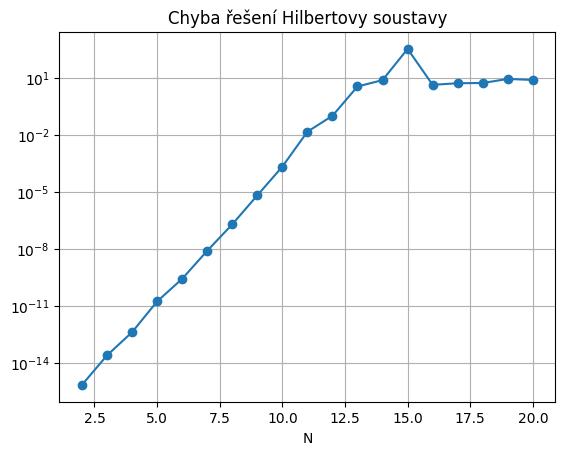

In [ ]:
def simpson_rule(f, a, b, n):
    """
    Numerický výpočet integrálu pomocí Simpsonova pravidla.
    
    :param f: Integrovaná funkce
    :param a: Dolní mez
    :param b: Horní mez
    :param n: Počet dělení (musí být sudé a >= 2)
    :return: Přibližná hodnota integrálu
    """
    # Simpson vyžaduje sudý počet intervalů (n+1 bodů)
    if n < 2 or n % 2 != 0:
        print("Chyba: n musí být sudé a >= 2.")
        return None

    h = (b - a) / n
    # Začneme součtem krajních hodnot f(a) + f(b)
    total_sum = f(a) + f(b)

    for i in range(1, n):
        x = a + i * h
        # Body v lichých pozicích se násobí 4, v sudých 2
        if i % 2 == 0:
            total_sum += 2 * f(x)
        else:
            total_sum += 4 * f(x)

    # Konečný vzorec: (h/3) * (f(a) + 4*f(x1) + 2*f(x2) + 4*f(x3) + ... + f(b))
    approximation = (h / 3) * total_sum
    return approximation


def gauss(a, b):
    """
    Řešení soustavy lineárních rovnic Ax = b pomocí Gaussovy eliminace.

    :param a: Matice soustavy (seznam seznamů, čtvercová n×n)
    :param b: Vektor pravé strany (délka n)
    :return: Vektor řešení x nebo None při selhání
    """
    n = len(b)
    
    # Kontrola rozměrů (čtvercová matice)
    if n != len(a) or any(len(row) != n for row in a):
        print("Chyba: Nesouhlasí délky vstupních dat.")
        return None

    # Vytvoření rozšířené matice (Bind v Go)
    # V Pythonu vytvoříme kopii, abychom nezměnili původní data
    ab = []
    for i in range(n):
        ab.append(list(a[i]) + [b[i]])

    # 1. Přímý chod (vytvoření horní trojúhelníkové matice)
    for k in range(n - 1):
        # Poznámka: V praxi by zde měl být "pivoting" (prohození řádků), 
        # aby ab[k][k] nebylo nula.
        for i in range(k + 1, n):
            c = -ab[i][k] / ab[k][k]
            for j in range(k, n + 1):
                ab[i][j] += c * ab[k][j]

    # 2. Zpětný chod (výpočet hodnot neznámých x)
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        sum_val = ab[i][n]
        for j in range(i + 1, n):
            sum_val -= ab[i][j] * x[j]
        
        x[i] = sum_val / ab[i][i]
        
    return x


def build_matrix(N):
    """
    Sestaví matici A (N×N) kde A[i][j] = 1 - 1/(i+j+1).
    Výjimka: A[0][0] = 0 (i+j+1=1, výsledek 1-1/1=0).

    :param N: Rozměr matice
    :return: Matice A jako seznam seznamů
    """
    A = []
    for i in range(1,N+1):
        row = []
        for j in range(1,N+1):
            if i == 0 and j == 0:
                row.append(0.0) 
            else:
                row.append(simpson_rule((lambda t: t**(i+j-2)),0,1,100))
        A.append(row)
    return A






celkove_chyby = []
celkove_reseni = []

for N in range(2,21):
    matr = build_matrix(N)
    b = []
    for row in matr:
        b.append(sum(row))
    reseni = gauss(matr,b)
    celkove_reseni.append(reseni)
    chyba = max(abs(x - 1.0) for x in reseni)
    celkove_chyby.append(chyba)

print(celkove_reseni)
print(celkove_chyby)
print(len(celkove_reseni))
print(len(celkove_chyby))


# matr = build_matrix(20)
# print(matr)
# print(len(matr))


# b = []
# for row in matr:
#     b.append(sum(row))

# print(b)
# print(len(b))

# reseni = gauss(matr,b)

# print(reseni)



import matplotlib.pyplot as plt

plt.semilogy(range(2, 21), celkove_chyby, marker='o')
plt.xlabel("N")
plt.title("Chyba řešení Hilbertovy soustavy")
plt.grid(True)
plt.show()




# Matice A je Hilbertova matice — jedna z nejznámějších špatně podmíněných matic.
# Číslo podmíněnosti kappa(A) roste přibližně exponenciálně s N (kappa ~ e^(3.5*N)).
# Od N~12 začne Gaussova eliminace akumulovat chyby zaokrouhlení natolik,
# že výsledek ztrácí smysl i přesto, že analytické řešení x = 1 existuje pro každé N.

# KI/NUM — zápočtová úloha č. 2

**Jiří Škvor**

---

## Zadání

Mějme následující experimentální data:

| $x$ | 0.0 | 0.5 | 1.0 | 1.5 | 2.0 | 2.5 | 3.0 |
|-----|-----|-----|-----|-----|-----|-----|-----|
| $y$ | 1.0 | 1.7 | 2.2 | 2.6 | 2.9 | 3.1 | 3.2 |

Data proložte interpolačním polynomem (vlastní implementace — Lagrange nebo Newton ze svého repozitáře). Vykreslete datové body spolu s interpolačním polynomem na intervalu $[0, 3]$ a určete hodnotu polynomu v bodě $x = 1.25$.

---

## Odevzdání

- Jeden `.py` soubor s komentáři
- Graf jako součást výstupu skriptu
- Výpis hodnoty $p(1.25)$ do konzole

2.41181640625


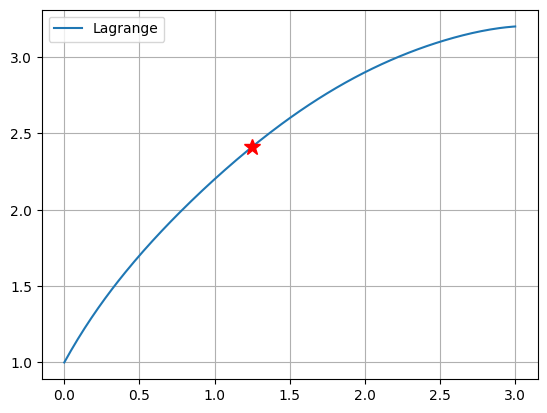

p(1.25) = 2.411816


In [17]:


def lagrange(x_vals, y_vals, t):
    """
    Lagrangeova interpolace — vyhodnotí interpolační polynom v bodě t.

    Každý bázový polynom L_i(t) = ∏(t - x_j)/(x_i - x_j) pro j ≠ i.
    Výsledek: P(t) = Σ y_i * L_i(t)

    :param x_vals: Uzlové body x (seznam, délka n)
    :param y_vals: Hodnoty funkce v uzlech (seznam, délka n)
    :param t: Bod nebo seznam bodů pro vyhodnocení
    :return: Interpolovaná hodnota (nebo seznam hodnot)
    """
    if len(x_vals) != len(y_vals) or len(x_vals) == 0:
        print("Chyba: Nesouhlasí délky nebo prázdný vstup.")
        return None

    n = len(x_vals)
    t_list = t if isinstance(t, list) else [t]
    result = []

    for val in t_list:
        p = 0.0
        for i in range(n):
            L = 1.0
            for j in range(n):
                if j != i:
                    denom = x_vals[i] - x_vals[j]
                    if abs(denom) < 1e-14:
                        print("Chyba: Duplicitní uzly.")
                        return None
                    L *= (val - x_vals[j]) / denom
            p += y_vals[i] * L
        result.append(p)

    return result if isinstance(t, list) else result[0]





x = [ 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

y = [1.0, 1.7, 2.2, 2.6, 2.9, 3.1, 3.2]

result = lagrange(x,y,1.25)

print(result)

import numpy as np
import matplotlib.pyplot as plt

x_line = list(np.linspace(0,3,200))
y_line = lagrange(x,y, x_line)
plt.figure()
plt.plot(x_line, y_line, '-', label='Lagrange')
plt.grid(True)
plt.legend()
plt.plot(1.25, result, 'r*', markersize=12, label='p(1.25)')
plt.show()
print(f'p(1.25) = {result:.6f}')


# KI/NUM — zápočtová úloha č. 3

**Jiří Škvor**

---

## Zadání

Nalezněte kořen rovnice

$$f(x) = x^3 - x - 2 = 0$$

na intervalu $[1, 2]$ s přesností $10^{-8}$ metodou bisekce (vlastní implementace). Vypište počet iterací potřebných ke konvergenci a ověřte výsledek dosazením zpět do $f(x)$.

---

## Odevzdání

- Jeden `.py` soubor s komentáři
- Výpis nalezeného kořene, počtu iterací a hodnoty $f(x)$ do konzole

In [27]:
def bisection(f, a, b, tol, max_iter, verbose=False):
    """
    Numerické hledání kořene funkce pomocí metody půlení intervalu.

    :param f: Funkce, jejíž kořen hledáme
    :param a: Levá mez intervalu
    :param b: Pravá mez intervalu
    :param tol: Tolerance (přesnost)
    :param max_iter: Maximální počet iterací
    :param verbose: Vypisovat průběh iterací (default False)
    :return: Kořen funkce nebo None, pokud metoda selže
    """
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        print("Chyba: Žádná změna znaménka, kořen v intervalu nelze zaručit.")
        return None

    c = a
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)

        if verbose:
            print(f"Iterace {i+1:3d}: c = {c:.10f}, f(c) = {fc:.4e}, délka intervalu = {(b-a)/2:.4e}")

        if abs(fc) < tol or (b - a) / 2 < tol:
            if verbose:
                print(f"Konvergoval v iteraci {i+1}.")
            return c

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    print("Chyba: Metoda neskonvergovala.")
    return None


funkce = lambda x: x**3 - x -2

#x = (x-2)**1/3

vysledek = bisection(funkce,1,2,10**(-8),100,verbose=True)

print(f"dosazení c : {funkce(1.5213797018)}")

Iterace   1: c = 1.5000000000, f(c) = -1.2500e-01, délka intervalu = 5.0000e-01
Iterace   2: c = 1.7500000000, f(c) = 1.6094e+00, délka intervalu = 2.5000e-01
Iterace   3: c = 1.6250000000, f(c) = 6.6602e-01, délka intervalu = 1.2500e-01
Iterace   4: c = 1.5625000000, f(c) = 2.5220e-01, délka intervalu = 6.2500e-02
Iterace   5: c = 1.5312500000, f(c) = 5.9113e-02, délka intervalu = 3.1250e-02
Iterace   6: c = 1.5156250000, f(c) = -3.4054e-02, délka intervalu = 1.5625e-02
Iterace   7: c = 1.5234375000, f(c) = 1.2250e-02, délka intervalu = 7.8125e-03
Iterace   8: c = 1.5195312500, f(c) = -1.0971e-02, délka intervalu = 3.9062e-03
Iterace   9: c = 1.5214843750, f(c) = 6.2218e-04, délka intervalu = 1.9531e-03
Iterace  10: c = 1.5205078125, f(c) = -5.1789e-03, délka intervalu = 9.7656e-04
Iterace  11: c = 1.5209960938, f(c) = -2.2794e-03, délka intervalu = 4.8828e-04
Iterace  12: c = 1.5212402344, f(c) = -8.2891e-04, délka intervalu = 2.4414e-04
Iterace  13: c = 1.5213623047, f(c) = -1.0343e

# KI/NUM — zápočtová úloha č. 4

**Jiří Škvor**

---

## Zadání

Nalezněte $p$ takové, aby platilo:

$$\int_0^p \left( \int_0^{2\pi} e^{-\alpha x} \sin x \, dx \right) d\alpha = 1.31848$$

Použijte vlastní implementaci Simpsonova pravidla pro oba integrály a vlastní implementaci bisekce pro nalezení $p$. Výsledek ověřte dosazením zpět.

---

## Odevzdání

- Jeden `.py` soubor s komentáři
- Výpis nalezeného $p$ a ověření dosazením do dvojného integrálu

In [16]:
from multiprocessing.resource_sharer import stop

def bisection(f, a, b, tol, max_iter, verbose=False):
    """
    Numerické hledání kořene funkce pomocí metody půlení intervalu.

    :param f: Funkce, jejíž kořen hledáme
    :param a: Levá mez intervalu
    :param b: Pravá mez intervalu
    :param tol: Tolerance (přesnost)
    :param max_iter: Maximální počet iterací
    :param verbose: Vypisovat průběh iterací (default False)
    :return: Kořen funkce nebo None, pokud metoda selže
    """
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        print("Chyba: Žádná změna znaménka, kořen v intervalu nelze zaručit.")
        return None

    c = a
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)

        if verbose:
            print(f"Iterace {i+1:3d}: c = {c:.10f}, f(c) = {fc:.4e}, délka intervalu = {(b-a)/2:.4e}")

        if abs(fc) < tol or (b - a) / 2 < tol:
            if verbose:
                print(f"Konvergoval v iteraci {i+1}.")
            return c

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    print("Chyba: Metoda neskonvergovala.")
    return None

# Příklad použití:
# root = bisection(lambda x: x**2 - 4, 0, 5, 1e-6, 100)
# print(f"Kořen je: {root}")


def simpson_rule(f, a, b, n):
    """
    Numerický výpočet integrálu pomocí Simpsonova pravidla.
    
    :param f: Integrovaná funkce
    :param a: Dolní mez
    :param b: Horní mez
    :param n: Počet dělení (musí být sudé a >= 2)
    :return: Přibližná hodnota integrálu
    """
    # Simpson vyžaduje sudý počet intervalů (n+1 bodů)
    if n < 2 or n % 2 != 0:
        print("Chyba: n musí být sudé a >= 2.")
        return None

    h = (b - a) / n
    # Začneme součtem krajních hodnot f(a) + f(b)
    total_sum = f(a) + f(b)

    for i in range(1, n):
        x = a + i * h
        # Body v lichých pozicích se násobí 4, v sudých 2
        if i % 2 == 0:
            total_sum += 2 * f(x)
        else:
            total_sum += 4 * f(x)

    # Konečný vzorec: (h/3) * (f(a) + 4*f(x1) + 2*f(x2) + 4*f(x3) + ... + f(b))
    approximation = (h / 3) * total_sum
    return approximation




import math

def vnitrni(alpha):
    vnitrtni_funkce = lambda x: math.e**(-alpha*x) * math.sin(x)
    
    return simpson_rule(vnitrtni_funkce,0,2*math.pi,100)

def vnejsi(p):
    return simpson_rule(vnitrni,0,p,100)


finalniP = lambda p: vnejsi(p) - 1.31848
print(finalniP)

p_result = bisection(finalniP, 0.1, 20, 1e-8, 100)

print(p_result)

print(f'p = {p_result:.8f}')


print(f'ověření: {vnejsi(p_result):.8f}')

print(f'ověření: {vnejsi(10.01959587):.8f}')



<function <lambda> at 0x7f8106621900>
10.019595867395404
p = 10.01959587
ověření: 1.31848000
ověření: 1.31848000


# KI/NUM — zápočtová úloha č. 5

**Jiří Škvor**

---

## Zadání

Nalezněte $p$ takové, aby platilo:

$$\int_0^p \left( \int_0^{\pi} e^{-\alpha x} \cos x \, dx \right) d\alpha = 0.85$$

Použijte vlastní implementaci Simpsonova pravidla pro oba integrály a vlastní implementaci bisekce pro nalezení $p$. Výsledek ověřte dosazením zpět.

---

## Odevzdání

- Jeden `.py` soubor s komentáři
- Výpis nalezeného $p$ a ověření dosazením do dvojného integrálu

In [41]:

target = 0.85



def vnitrni(alpha):      #2 argumenty mit nemuzu momentalne proto si alfu zadefinujeme tak ze ji vlozime do funkce
    vni_fce = lambda x: math.e**(-alpha*x) * math.cos(x)
    return simpson_rule(vni_fce,0,math.pi,100)

def vnejsi(p):
    vysledek2 = simpson_rule(vnitrni,0,p,100)  
    return vysledek2


temp = lambda p: vnejsi(p) - target #tim ziskam funkcni pro bisekci 

final = bisection(temp,0.1,20,1e-15,1000,verbose=False)



print(final)

overeni = vnejsi(final)

if round(overeni,5) == round(target,5):
    print("Úspěch")
    print(f"{round(overeni,5)}" ,f"{round(target,5):}")
else:
    print("kurnik")






1.9304529694115002
Úspěch
0.85 0.85


# KI/NUM — zápočtová úloha č. 6

**Jiří Škvor**

---

## Zadání

Mějme diferenciální rovnici

$$y'(x) - y + x = 0$$

pro kterou platí

$$\int_0^1 y(x) \, dx = 2$$

Nalezněte řešení $y(x)$ na intervalu $[0, 1]$. Použijte metodu střelby — vlastní implementaci RK4 pro integraci ODR a vlastní implementaci bisekce pro nalezení počáteční podmínky $y(0)$. Vykreslete nalezené řešení.

---

## Nápověda

- ODR přepište do tvaru $y' = f(x, y)$
- RK4 potřebuje počáteční podmínku $y(0) = s$ — tu hledáte bisekci
- Integrál $\int_0^1 y(x) \, dx$ spočítejte lichoběžníkovým pravidlem z bodů které vrátí RK4

---

## Odevzdání

- Jeden `.py` soubor s komentáři
- Výpis nalezeného $y(0)$ a ověření integrálu
- Graf $y(x)$ na intervalu $[0, 1]$

In [98]:
def euler_step_points(f, x0, y0, h, n, verbose=False):
    """
    Numerické řešení ODE pomocí Eulerovy metody.
    Varianta vracející seznam dvojic (x, y) místo pouze hodnot y.

    :param f: Funkce f(x, y) představující derivaci dy/dx
    :param x0: Počáteční hodnota x
    :param y0: Počáteční hodnota y
    :param h: Délka kroku
    :param n: Počet kroků
    :param verbose: Vypisovat průběh kroků (default False)
    :return: Seznam dvojic (x, y)
    """
    if n < 1:
        print("Chyba: Počet kroků n musí být >= 1.")
        return None

    body = [(x0, y0)]

    x = x0
    y = y0

    if verbose:
        print(f"Krok   0: x = {x:.4f}, y = {y:.10f}")

    for i in range(1, n + 1):
        y = y + h * f(x, y)
        x = x + h
        body.append((x, y))
        if verbose:
            print(f"Krok {i:3d}: x = {x:.4f}, y = {y:.10f}")

    return body

def trapezoid_points(body):
    """
    Lichoběžníkové pravidlo přímo na seznamu bodů (x, y).
    
    :param body: Seznam dvojic (x, y)
    :return: Odhad integrálu
    """
    result = 0.0
    for i in range(len(body) - 1):
        x1, y1 = body[i]
        x2, y2 = body[i+1]
        result += 0.5 * (y1 + y2) * (x2 - x1)
    return result
    

def function(x, y):
    return y - x

def residuals(s):     #s = y0
    
    return trapezoid_points(euler_step_points(function,0,s,0.01,100,verbose=False)) - 2.0


print(round(residuals(2.46),2))


s_opt = bisection(residuals, 0, 10, 1e-8, 100)
print(f"y(0) = {s_opt:.8f}")

print(f"ověření integrálu: {trapezoid_points(euler_step_points(function, 0, 1.29182802, 0.01, 100)):.8f}")

2.0
y(0) = 1.29182802
ověření integrálu: 2.00000001


# Procvičení — přepis diferenciálních rovnic do tvaru y' = f(x, y)

---

Pro každou rovnici napiš funkci `f(x, y)` tak aby platilo `y' = f(x, y)`.

---

**1.** $y' + 2y = 0$

**2.** $y' = x^2 + y$

**3.** $y' - 3y + x^2 = 0$

**4.** $2y' + y = \sin(x)$

In [42]:
# 1) 

def f1(x, y):
    return 2*y


def f2(x,y):
    return x**2 + y


def f3(x, y):
    return -3*y + x**2

def f4(x, y):
    return (math.sin(x) - y) / 2